In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [19]:
df=pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [20]:
df.shape

(3556, 18)

In [21]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 15,1.07,11889.0,2,2,1,1.0,Old Property,900.0,0,1,0,0,0,0,7
1,flat,ats tourmaline,sector 109,1.75,8140.0,3,4,3+,9.0,Relatively New,1946.0,0,1,0,0,0,0,94
2,flat,paras dews,sector 106,1.10,9735.0,3,4,3+,8.0,Relatively New,1186.0,0,1,0,0,0,1,174
3,house,independent,sector 12,1.00,8230.0,3,7,3+,3.0,Moderately Old,3750.0,0,0,1,1,0,0,7
4,house,international city by sobha phase 1,sector 109,6.00,24691.0,4,5,3+,2.0,Relatively New,2430.0,0,1,0,0,0,1,96


In [22]:
latlong= pd.read_csv('latlong.csv')


In [23]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [24]:
latlong['latitude']=latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [25]:
latlong['latitude']

0      28.3663
1      28.5095
2      28.4909
3      28.4738
4      28.4794
        ...   
124    28.5287
125    28.5334
126    28.5385
127    28.4484
128    28.3515
Name: latitude, Length: 129, dtype: float64

In [26]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [27]:

latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [28]:
new_df=df.merge(latlong, on='sector')

In [29]:
new_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,...,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,coordinates,latitude,longitude
0,house,independent,sector 15,1.07,11889.0,2,2,1,1.0,Old Property,...,0,1,0,0,0,0,7,"28.4621° N, 77.0464° E",28.4621,77.0464
1,flat,ats tourmaline,sector 109,1.75,8140.0,3,4,3+,9.0,Relatively New,...,0,1,0,0,0,0,94,"28.5073° N, 77.0089° E",28.5073,77.0089
2,flat,paras dews,sector 106,1.10,9735.0,3,4,3+,8.0,Relatively New,...,0,1,0,0,0,1,174,"28.5007° N, 77.0003° E",28.5007,77.0003
3,house,independent,sector 12,1.00,8230.0,3,7,3+,3.0,Moderately Old,...,0,0,1,1,0,0,7,"28.4723° N, 77.0320° E",28.4723,77.0320
4,house,international city by sobha phase 1,sector 109,6.00,24691.0,4,5,3+,2.0,Relatively New,...,0,1,0,0,0,1,96,"28.5073° N, 77.0089° E",28.5073,77.0089


In [30]:
group_df = new_df.groupby('sector')[['price','price_per_sqft','built_up_area','latitude','longitude']].mean()


In [31]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
sector 103,1.495000,7445.785714,1865.428571,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.929100,5970.430000,1559.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326
sector 95,0.466167,5140.466667,5806.033333,28.4172,76.9081


C:\Users\hp\AppData\Local\Temp\ipykernel_28880\566878740.py:3: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



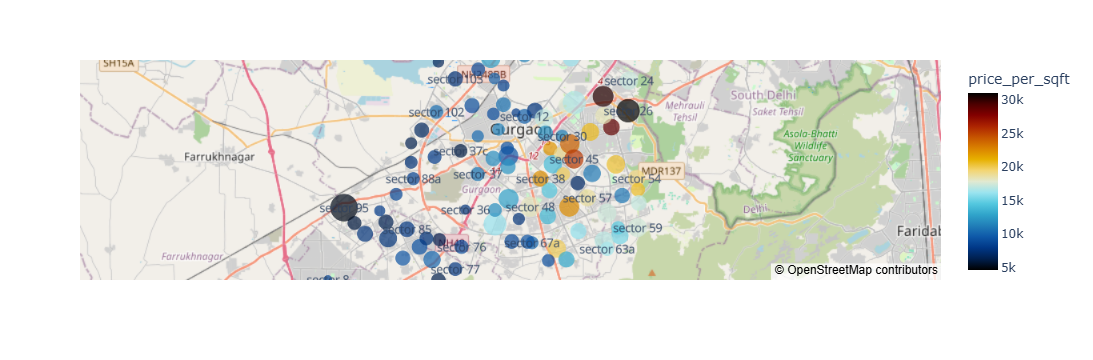

In [32]:
# this code is copied from plotly to plot geo-map

fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [33]:
new_df.to_csv('data_vi1.csv',index=False)

In [34]:
df1= pd.read_csv('gurgaon_properties.csv')

In [35]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,2 Bedroom House for sale in Patel Nagar,house,independent,1.07,11888.0,900.0,Plot area 900(83.61 sq.m.),2,2,1,servant room,"Patel Nagar, Gurgaon, Haryana",1.0,NaN,10+ Year Old,"['Hanuman Mandir', 'State bank of india ATM', ...",It is located at the central location and is t...,NaN,['Water Storage'],"['Environment4 out of 5', 'Lifestyle4 out of 5..."
1,3 BHK Flat in Sector 109 Gurgaon,flat,ats tourmaline,1.75,8139.0,2150.0,Super Built up area 2150(199.74 sq.m.),3,4,3+,servant room,"N/a, Sector 109 Gurgaon, Gurgaon, Haryana",9.0,North-East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'NeoSquare ...",This lovely 3 bhk apartment/flat in sector 109...,[],"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area4.5 out of 5', 'Construction4.5 ou..."
2,4 BHK Flat in Sector 106 Gurgaon,flat,paras dews,1.40,9978.0,1403.0,Super Built up area 2355(218.79 sq.m.)Built Up...,4,6,3+,servant room,"D444, Sector 106 Gurgaon, Gurgaon, Haryana",10.0,North-West,1 to 5 Year Old,"['MG Road Metro Station', 'NeoSquare Shopping ...","Situated in sector 106 gurgaon, paras dews is ...",NaN,"['Centrally Air Conditioned', 'Water purifier'...",NaN
3,3 BHK Flat in Sector 106 Gurgaon,flat,paras dews,1.10,9734.0,1130.0,Super Built up area 1760(163.51 sq.m.)Built Up...,3,4,3+,servant room,"Sector 106 Gurgaon, Sector 106 Gurgaon, Gurgao...",8.0,North-West,1 to 5 Year Old,"['MG Road Metro Station', 'NeoSquare Shopping ...",This 3 bhk apartment is available for sale in ...,"['3 Wardrobe', '1 Water Purifier', '3 Fan', '1...","['Centrally Air Conditioned', 'Water purifier'...",NaN
4,9 Bedroom House for sale in Dharam Colony,house,independent,1.00,74074.0,135.0,Plot area 135(12.54 sq.m.)Built Up area: 3750 ...,9,7,3+,"pooja room,store room","F-121, Dharam Colony, Gurgaon, Haryana",3.0,North,5 to 10 Year Old,"['Palam triangle', 'Palam Vihar Vyapar kendra'...","Two side open, north and south facing 20 feet ...",NaN,"['No open drainage around', 'Internet/wi-fi co...","['Environment4 out of 5', 'Lifestyle4 out of 5..."


In [37]:
wordcloud_df=df1.merge(df,left_index=True, right_index=True)[['features','sector']]

In [38]:
wordcloud_df.head()

,features,sector
0,['Water Storage'],sector 15
1,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 109
2,"['Centrally Air Conditioned', 'Water purifier'...",sector 106
3,"['Centrally Air Conditioned', 'Water purifier'...",sector 12
4,"['No open drainage around', 'Internet/wi-fi co...",sector 109


In [39]:
wordcloud_df.dtypes

features    object
sector      object
dtype: object

In [41]:
# Now we will store this feature in an array

import ast 
main=[]
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [42]:
main

['Water Storage',
 'Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Separate entry for servant room',
 'No open drainage around',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Internet/wi-fi connectivity',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Water softening plant',
 'Centrally Air Conditioned',
 'Water purifier',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Recently Renovated',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Lo

In [43]:
# Now we will convert these features present inside the array into string
feature_text= ' '.join(main)

In [44]:
feature_text

'Water Storage Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Separate entry for servant room No open drainage around Visitor Parking Swimming Pool Park Internet/wi-fi connectivity Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Water softening plant Centrally Air Conditioned Water purifier Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Centrally Air Conditioned Wat

In [45]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [46]:
from wordcloud import WordCloud

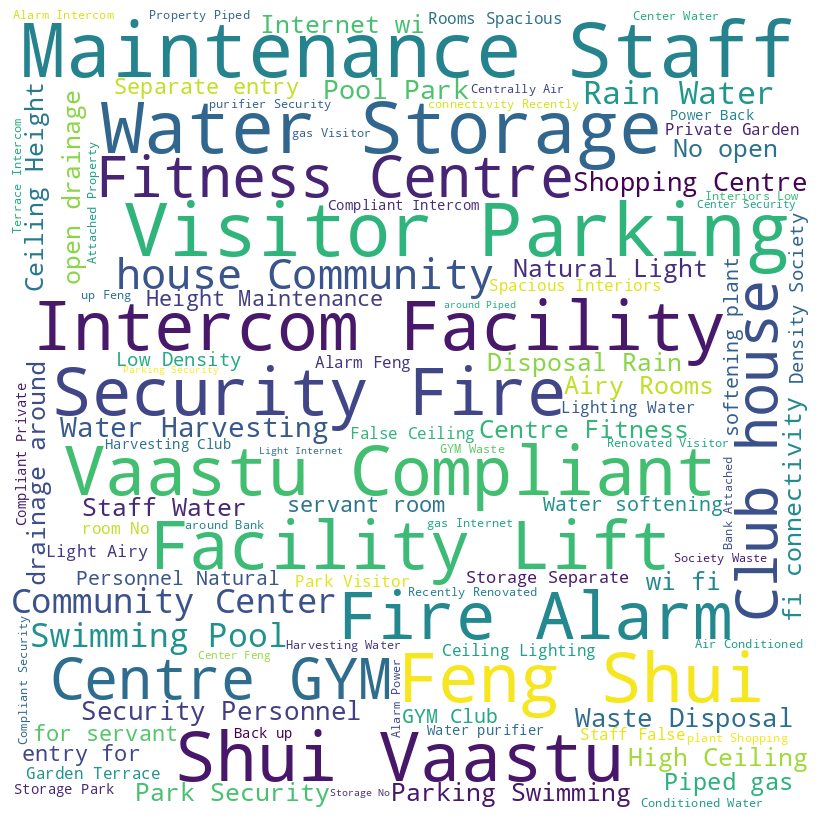

In [47]:

plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

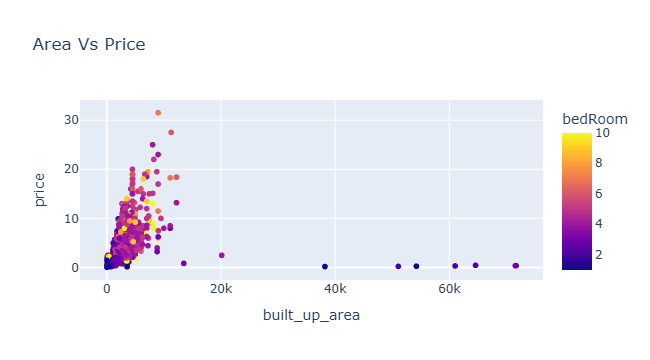

In [51]:
# Scatter Plot bw Area vs Price

fig= px.scatter(df,x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")
fig.show()

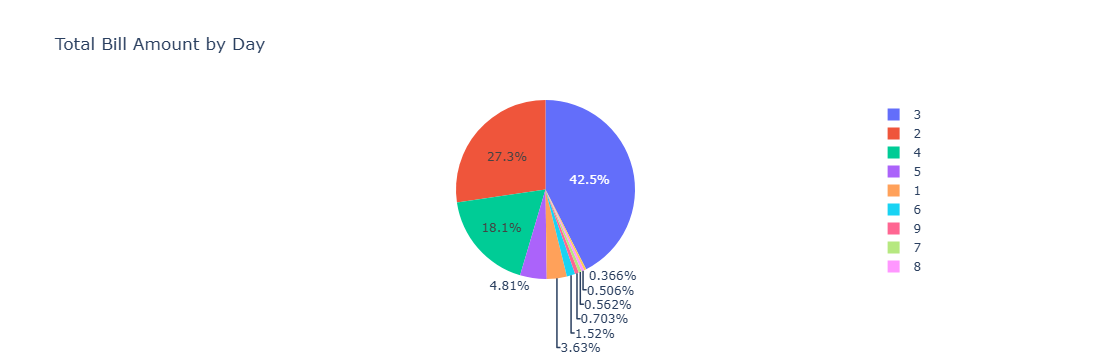

In [55]:
# ploting pie chart of bedroom Data
fig= px.pie(df, names='bedRoom',title='BHK Pie chart')
fig.show()

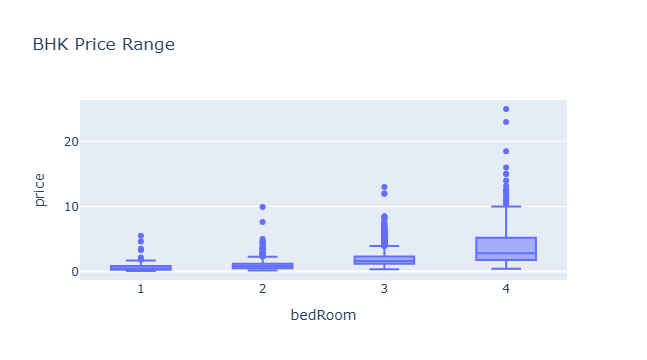

In [57]:
# Side by side Box plot Sector Wise which give price rage for every bedroom no 

temp_df= df[df['bedRoom'] <=4]
# Create side-by- side boxplot of the total bill amounts by Day

fig= px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')
fig.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_28880\3626959792.py:3: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\hp\AppData\Local\Temp\ipykernel_28880\3626959792.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

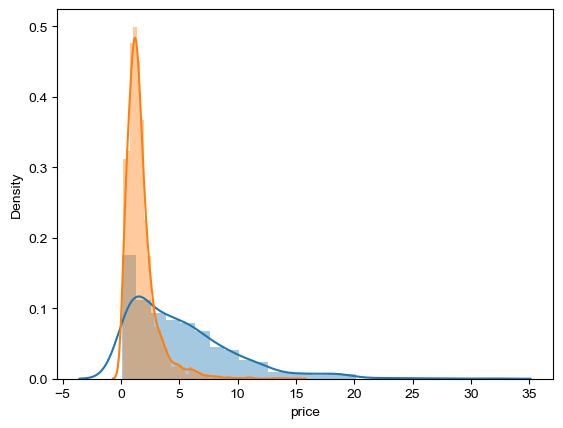

In [58]:
# distribution plot of price of flat and house

sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])
